In [1]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [4]:
import pandas as pd


In [6]:
df = pd.read_excel(r"C:\Users\admin\Downloads\Retail_Banking_Project\Merged_retail_banking.xlsx")

In [7]:
print(df.shape)
df.head()

(24000, 16)


,customer_id,age,region,preferred_channel,monthly_transactions_avg,avg_monthly_balance,num_products_held,digital_adoption_score,credit_card_issued,loan_taken,Age_group,Balance_Category,month,monthly_transactions,Month_Name,Active customer
0,CUST100007,56,South,ATM,23,37632,2,0.52,0,0,46-60,Medium,2022-01-01,15,January,yes
1,CUST100007,56,South,ATM,23,37632,2,0.52,0,0,46-60,Medium,2022-02-01,12,February,No
2,CUST100007,56,South,ATM,23,37632,2,0.52,0,0,46-60,Medium,2022-03-01,20,March,yes
3,CUST100007,56,South,ATM,23,37632,2,0.52,0,0,46-60,Medium,2022-04-01,21,April,yes
4,CUST100007,56,South,ATM,23,37632,2,0.52,0,0,46-60,Medium,2022-05-01,19,May,yes


In [8]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Select features
selected_features = [
    'monthly_transactions_avg',
    'avg_monthly_balance',
    'num_products_held',
    'digital_adoption_score',
    'preferred_channel',
    'credit_card_issued',
    'loan_taken',
    'Active customer'
]

segmentation_df = df[selected_features].copy()

In [9]:
# One-hot encode categorical columns
segmentation_df = pd.get_dummies(
    segmentation_df,
    columns=[
        'preferred_channel',
        'credit_card_issued',
        'loan_taken',
        'Active customer'
    ],
    drop_first=True
)

In [10]:
# Scale the data
scaler = StandardScaler()

segmentation_scaled = pd.DataFrame(
    scaler.fit_transform(segmentation_df),
    columns=segmentation_df.columns
)

print(segmentation_scaled.shape)
segmentation_scaled.head()

(24000, 10)


,monthly_transactions_avg,avg_monthly_balance,num_products_held,digital_adoption_score,preferred_channel_Branch,preferred_channel_Mobile App,preferred_channel_Online Banking,credit_card_issued_1,loan_taken_1,Active customer_yes
0,0.643,-0.797903,0.044953,0.112372,-0.592749,-0.560411,-0.581969,-0.645314,-0.507801,0.539588
1,0.643,-0.797903,0.044953,0.112372,-0.592749,-0.560411,-0.581969,-0.645314,-0.507801,-1.853265
2,0.643,-0.797903,0.044953,0.112372,-0.592749,-0.560411,-0.581969,-0.645314,-0.507801,0.539588
3,0.643,-0.797903,0.044953,0.112372,-0.592749,-0.560411,-0.581969,-0.645314,-0.507801,0.539588
4,0.643,-0.797903,0.044953,0.112372,-0.592749,-0.560411,-0.581969,-0.645314,-0.507801,0.539588


In [11]:
#Find the Optimal Number of Clusters (Elbow Method)
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        max_iter=300,
        n_init=10,
        random_state=42
    )

    kmeans.fit(segmentation_scaled)

    wcss.append(kmeans.inertia_)

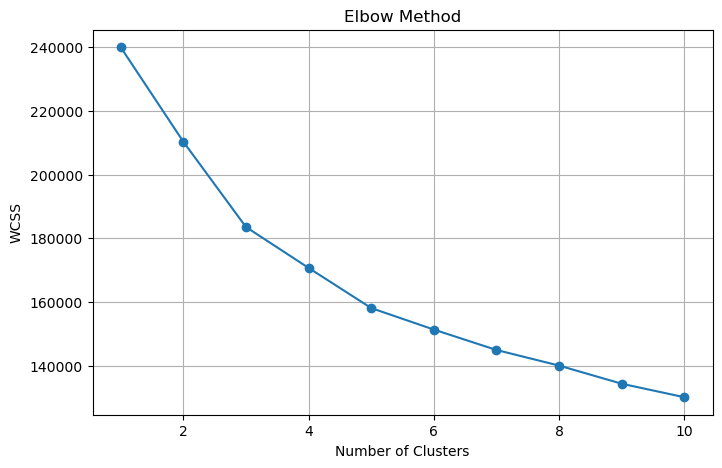

In [12]:
#Plot the Elbow Curve
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [13]:
#Select the Optimal Number of Clusters
optimal_clusters = 4

In [14]:
#Train the Final K-Means Model
kmeans = KMeans(
    n_clusters=optimal_clusters,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=42
)

clusters = kmeans.fit_predict(segmentation_scaled)

In [15]:
#Assign Cluster IDs
segmentation_scaled["Cluster"] = clusters


In [16]:
df["Cluster"] = clusters

In [17]:
#Check Cluster Sizes
print(df["Cluster"].value_counts())

Cluster
3    9600
0    5016
1    4920
2    4464
Name: count, dtype: int64


In [18]:
#Calculate Cluster Profiles
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

cluster_summary

,age,monthly_transactions_avg,avg_monthly_balance,num_products_held,digital_adoption_score,credit_card_issued,loan_taken,monthly_transactions
Cluster,,,,,,,,
0,43.913876,20.401914,49578.339713,1.966507,0.468086,0.315789,0.0,20.022927
1,43.107317,19.990244,48102.678049,1.980488,0.484780,0.287805,1.0,20.447154
2,43.752688,20.032258,50415.559140,2.021505,0.473763,0.306452,0.0,20.317652
3,43.855000,20.072500,50621.852500,1.907500,0.505550,0.280000,0.0,19.859792


In [19]:
#Compare Important Features
important_features = [

    "monthly_transactions_avg",

    "avg_monthly_balance",

    "num_products_held",

    "digital_adoption_score"

]

df.groupby("Cluster")[important_features].mean()

,monthly_transactions_avg,avg_monthly_balance,num_products_held,digital_adoption_score
Cluster,,,,
0,20.401914,49578.339713,1.966507,0.468086
1,19.990244,48102.678049,1.980488,0.484780
2,20.032258,50415.559140,2.021505,0.473763
3,20.072500,50621.852500,1.907500,0.505550


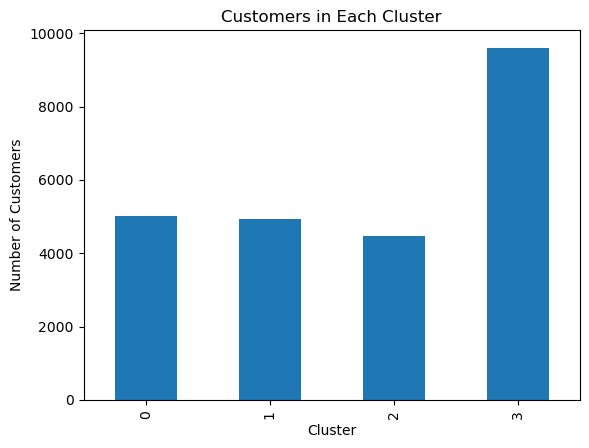

In [20]:
#Check Cluster Distribution
import matplotlib.pyplot as plt

df["Cluster"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Customers in Each Cluster")

plt.xlabel("Cluster")

plt.ylabel("Number of Customers")

plt.show()

In [21]:
#Check Cluster Centers
cluster_centers = pd.DataFrame(

    kmeans.cluster_centers_,

    columns=segmentation_scaled.drop("Cluster", axis=1).columns

)

cluster_centers

,monthly_transactions_avg,avg_monthly_balance,num_products_held,digital_adoption_score,preferred_channel_Branch,preferred_channel_Mobile App,preferred_channel_Online Banking,credit_card_issued_1,loan_taken_1,Active customer_yes
0,0.063545,-0.017674,0.010735,-0.067402,-0.592749,-0.560411,1.718304,0.047827,-0.507801,-0.010920
1,-0.028271,-0.114051,0.025018,-0.009591,0.007785,0.045810,-0.088252,-0.013598,1.969276,0.038159
2,-0.018900,0.037005,0.066924,-0.047742,-0.592749,1.784405,-0.581969,0.027331,-0.507801,0.023388
3,-0.009925,0.050479,-0.049550,0.062333,0.581350,-0.560411,-0.581969,-0.030729,-0.507801,-0.024726


Cluster Profiling & Business Interpretation

In [22]:
print("Customers in each Cluster")

print(df["Cluster"].value_counts().sort_index())

Customers in each Cluster
Cluster
0    5016
1    4920
2    4464
3    9600
Name: count, dtype: int64


In [23]:
#Calculate Cluster Summary
cluster_summary = df.groupby("Cluster").agg({

    "monthly_transactions_avg":"mean",

    "avg_monthly_balance":"mean",

    "num_products_held":"mean",

    "digital_adoption_score":"mean"

}).round(2)

cluster_summary

,monthly_transactions_avg,avg_monthly_balance,num_products_held,digital_adoption_score
Cluster,,,,
0,20.40,49578.34,1.97,0.47
1,19.99,48102.68,1.98,0.48
2,20.03,50415.56,2.02,0.47
3,20.07,50621.85,1.91,0.51


In [24]:
#Calculate Median Values
cluster_median = df.groupby("Cluster").median(numeric_only=True)

cluster_median

,age,monthly_transactions_avg,avg_monthly_balance,num_products_held,digital_adoption_score,credit_card_issued,loan_taken,monthly_transactions
Cluster,,,,,,,,
0,44.0,20.0,49918.0,2.0,0.490,0.0,0.0,20.0
1,43.0,20.0,49383.0,2.0,0.470,0.0,1.0,20.0
2,44.0,20.0,51067.5,2.0,0.465,0.0,0.0,21.0
3,44.0,20.0,51082.0,2.0,0.505,0.0,0.0,20.0


In [25]:
#Compare Clusters Side by Side
comparison = df.groupby("Cluster")[

    [

    "monthly_transactions_avg",

    "avg_monthly_balance",

    "num_products_held",

    "digital_adoption_score"

    ]

].mean().round(2)

comparison

,monthly_transactions_avg,avg_monthly_balance,num_products_held,digital_adoption_score
Cluster,,,,
0,20.40,49578.34,1.97,0.47
1,19.99,48102.68,1.98,0.48
2,20.03,50415.56,2.02,0.47
3,20.07,50621.85,1.91,0.51


In [27]:
#Product Ownership
product_summary = df.groupby("Cluster")["num_products_held"].mean().round(2)

product_summary

Cluster
0    1.97
1    1.98
2    2.02
3    1.91
Name: num_products_held, dtype: float64

In [ ]:
#Active Customer Percentage
active_summary = pd.crosstab(

    df["Cluster"],

    df["Active customer"],

    normalize="index"

)*100

active_summary.round(2)

In [28]:
#Preferred Banking Channel
channel_summary = pd.crosstab(

    df["Cluster"],

    df["preferred_channel"],

    normalize="index"

)*100

channel_summary.round(2)

preferred_channel,ATM,Branch,Mobile App,Online Banking
Cluster,,,,
0,0.00,0.00,0.00,100.00
1,26.34,26.34,25.85,21.46
2,0.00,0.00,100.00,0.00
3,48.50,51.50,0.00,0.00


In [29]:
#Loan Ownership
loan_summary = pd.crosstab(

    df["Cluster"],

    df["loan_taken"],

    normalize="index"

)*100


In [30]:
#Credit Card Ownership
card_summary = pd.crosstab(

    df["Cluster"],

    df["credit_card_issued"],

    normalize="index"

)*100

card_summary.round(2)

credit_card_issued,0,1
Cluster,,
0,68.42,31.58
1,71.22,28.78
2,69.35,30.65
3,72.00,28.00


In [31]:
#View All Cluster Statistics
print(cluster_summary)

print(active_summary)

print(channel_summary)

print(product_summary)

         monthly_transactions_avg  avg_monthly_balance  num_products_held  \
Cluster                                                                     
0                           20.40             49578.34               1.97   
1                           19.99             48102.68               1.98   
2                           20.03             50415.56               2.02   
3                           20.07             50621.85               1.91   

         digital_adoption_score  
Cluster                          
0                          0.47  
1                          0.48  
2                          0.47  
3                          0.51  


NameError: name 'active_summary' is not defined

In [32]:
print(type(df))
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
['customer_id', 'age', 'region', 'preferred_channel', 'monthly_transactions_avg', 'avg_monthly_balance', 'num_products_held', 'digital_adoption_score', 'credit_card_issued', 'loan_taken', 'Age_group', 'Balance_Category', 'month', 'monthly_transactions', 'Month_Name', 'Active customer', 'Cluster']


In [33]:
active_summary = pd.crosstab(
    df["Cluster"],
    df["Active customer"],
    normalize="index"
) * 100

active_summary.round(2)

Active customer,No,yes
Cluster,,
0,23.01,76.99
1,20.96,79.04
2,21.57,78.43
3,23.58,76.42


In [34]:
print(cluster_summary)

print(active_summary)

print(channel_summary)

print(product_summary)

         monthly_transactions_avg  avg_monthly_balance  num_products_held  \
Cluster                                                                     
0                           20.40             49578.34               1.97   
1                           19.99             48102.68               1.98   
2                           20.03             50415.56               2.02   
3                           20.07             50621.85               1.91   

         digital_adoption_score  
Cluster                          
0                          0.47  
1                          0.48  
2                          0.47  
3                          0.51  
Active customer         No        yes
Cluster                              
0                23.006380  76.993620
1                20.955285  79.044715
2                21.572581  78.427419
3                23.583333  76.416667
preferred_channel        ATM     Branch  Mobile App  Online Banking
Cluster                              